# This notebook contains scripts that generate figures of Clinical Variants experiment

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
# This result file has been generated by multiprocess_clinvar_analysis.py script.
res_data = pd.read_csv("result_files/clinvar_analysis.csv").drop(columns=["Unnamed: 0"])
# class balancing:
total_benign = 30727
total_patho = 32000
benign_scaler = total_patho / total_benign
res_data["sibling_count"] = res_data["sibling_count"].astype(float)
res_data.loc[res_data["dataset"] == "Benign", "sibling_count"] = (
    res_data.loc[res_data["dataset"] == "Benign", "sibling_count"] * benign_scaler
)
res_data.head()

,dataset,matrix,sibling_count,data_size,vocab_size,config,is_pre
0,Benign,blosum62,1295.538126,30727,800,0.7_3_12_0,False
1,Benign,blosum62,5069.678133,30727,51200,0.7_3_12_0.1,False
2,Benign,blosum62,691.509096,30727,1600,0.8_3_12_0.2,False
3,Benign,blosum62,2677.514889,30727,51200,0.8_3_12_0.2,False
4,Benign,blosum62,432.193185,30727,800,0.8_3_12_0.005,False


In [7]:
from Bio.Align import substitution_matrices
import pickle
matrix_counts = {
    "BLOSUM62": {}, 
    "BLOSUM45": {}, 
    "PAM250": {},
    "PAM70": {}
}
for matrix in matrix_counts.keys():
    subs_matrix = substitution_matrices.load(matrix)
    for dataset in ["pathogenic", "benign"]:
        with open(f"same_idx_work/datasets/df_{dataset}.pkl", "rb") as f:
            cur_df = pickle.load(f)
        mut_list = cur_df["mutant"].to_list()
        mut_list = [(int(mut[1:-1]) - 1, mut[0], mut[-1]) for mut in mut_list]
        c = 0
        for _, s, t in mut_list:
            if subs_matrix[s][t] >= -1e-4: c += 1
        if dataset == "benign":
            # reweight benign count for class balance
            matrix_counts[matrix][f"subs_{dataset}"] = c * benign_scaler
        else:
            matrix_counts[matrix][f"subs_{dataset}"] = c
matrix_counts

{'BLOSUM62': {'subs_pathogenic': 11236, 'subs_benign': 19861.09935887005},
 'BLOSUM45': {'subs_pathogenic': 11718, 'subs_benign': 20115.208123149023},
 'PAM250': {'subs_pathogenic': 20370, 'subs_benign': 25875.353923259678},
 'PAM70': {'subs_pathogenic': 10776, 'subs_benign': 18560.354085983014}}

In [8]:
pivot_df = res_data.pivot(
    index=['vocab_size', 'config', 'matrix'], 
    columns=['dataset'], 
    values='sibling_count'
).reset_index()
pivot_df = pivot_df.merge(
    pd.DataFrame.from_dict(matrix_counts, orient="index")
      .rename_axis("matrix")
      .reset_index()
      .assign(matrix=lambda d: d["matrix"].str.lower()),
    on="matrix",
    how="left"
)
pivot_df

,vocab_size,config,matrix,Benign,Pathogenic,subs_pathogenic,subs_benign
0,800,0.7_3_12_0,blosum45,1180.980896,548.0,11718,20115.208123
1,800,0.7_3_12_0,blosum62,1295.538126,585.0,11236,19861.099359
2,800,0.7_3_12_0,pam70,1025.807921,484.0,10776,18560.354086
3,800,0.7_3_12_0.005,blosum45,1197.643766,552.0,11718,20115.208123
4,800,0.7_3_12_0.005,blosum62,1325.739578,604.0,11236,19861.099359
...,...,...,...,...,...,...,...
380,51200,0.9_3_12_0.1,pam70,51.030039,24.0,10776,18560.354086
381,51200,0.9_3_12_0.2,blosum45,813.356332,114.0,11718,20115.208123
382,51200,0.9_3_12_0.2,blosum62,1277.833827,125.0,11236,19861.099359
383,51200,0.9_3_12_0.2,pam250,3285.709636,1554.0,20370,25875.353923


In [9]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# 1. Raw counts
a = pivot_df["Benign"].astype(float)
b = pivot_df["Pathogenic"].astype(float)
c = (pivot_df["subs_benign"]).astype(float)
d = (pivot_df["subs_pathogenic"]).astype(float)

# 2. Haldane-Anscombe Continuity Correction (add 0.5 if any cell in row is 0)
has_zero = (a == 0) | (b == 0) | (c == 0) | (d == 0)
a_adj = np.where(has_zero, a + 0.5, a)
b_adj = np.where(has_zero, b + 0.5, b)
c_adj = np.where(has_zero, c + 0.5, c)
d_adj = np.where(has_zero, d + 0.5, d)

# 3. Positive Rates & Risk Ratio
p1 = a_adj / (a_adj + b_adj)
p2 = c_adj / (c_adj + d_adj)

pivot_df["RR_enrichment"] = p1 / p2

# 4. Standard Error of log(RR) with explicit grouping parentheses
se_log_rr = np.sqrt(
    (1.0 / a_adj) - (1.0 / (a_adj + b_adj)) +
    (1.0 / c_adj) - (1.0 / (c_adj + d_adj))
)

# 5. Log-transformed Wald Z-test and Confidence Intervals
log_rr = np.log(pivot_df["RR_enrichment"])
z = log_rr / se_log_rr

pivot_df["RR_pvalue"] = 2 * norm.sf(np.abs(z))

z_alpha = 1.96  # 95% CI
pivot_df["RR_CI_low"] = np.exp(log_rr - z_alpha * se_log_rr)
pivot_df["RR_CI_high"] = np.exp(log_rr + z_alpha * se_log_rr)

# 6. Multiple Testing Correction (FDR / Benjamini-Hochberg)
_, pivot_df["RR_pvalue_fdr"], _, _ = multipletests(pivot_df["RR_pvalue"], method='fdr_bh')
pivot_df

,vocab_size,config,matrix,Benign,Pathogenic,subs_pathogenic,subs_benign,RR_enrichment,RR_pvalue,RR_CI_low,RR_CI_high,RR_pvalue_fdr
0,800,0.7_3_12_0,blosum45,1180.980896,548.0,11718,20115.208123,1.080957,4.270870e-06,1.045674,1.117432,4.779898e-06
1,800,0.7_3_12_0,blosum62,1295.538126,585.0,11236,19861.099359,1.078660,2.461698e-06,1.045211,1.113180,2.763130e-06
2,800,0.7_3_12_0,pam70,1025.807921,484.0,10776,18560.354086,1.073901,9.182782e-05,1.036209,1.112964,1.007228e-04
3,800,0.7_3_12_0.005,blosum45,1197.643766,552.0,11718,20115.208123,1.083263,1.889409e-06,1.048206,1.119493,2.126966e-06
4,800,0.7_3_12_0.005,blosum62,1325.739578,604.0,11236,19861.099359,1.075663,4.786873e-06,1.042563,1.109813,5.341873e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
380,51200,0.9_3_12_0.1,pam70,51.030039,24.0,10776,18560.354086,1.075005,3.617271e-01,0.920261,1.255770,3.847098e-01
381,51200,0.9_3_12_0.2,blosum45,813.356332,114.0,11718,20115.208123,1.388002,5.463280e-140,1.353038,1.423870,5.842674e-139
382,51200,0.9_3_12_0.2,blosum62,1277.833827,125.0,11236,19861.099359,1.426214,0.000000e+00,1.400242,1.452668,0.000000e+00
383,51200,0.9_3_12_0.2,pam250,3285.709636,1554.0,20370,25875.353923,1.213366,7.297781e-73,1.188156,1.239110,4.844217e-72


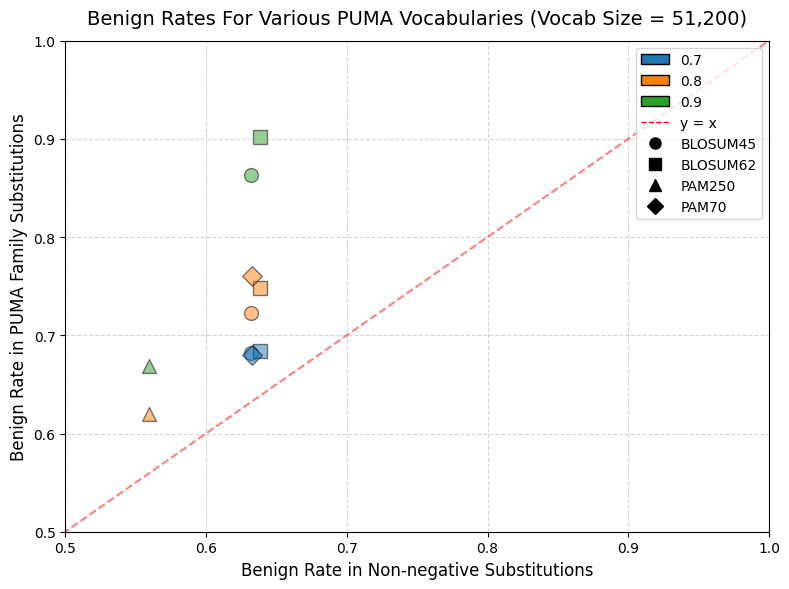

In [10]:
config_prefix = pivot_df["config"].astype(str).str[:3]
matrix_values = sorted(pivot_df["matrix"].unique())
prefix_values = sorted(config_prefix.unique())

cmap = plt.get_cmap("tab10")
# color_map = {pref: cmap(i % cmap.N) for i, pref in enumerate(matrix_values)}
color_map = {pref: cmap(i % cmap.N) for i, pref in enumerate(prefix_values)}

marker_list = ["o", "s", "^", "D", "P", "X", "*", "v", "<", ">", "H", "8", "p"]
# matrix_markers = {m: marker_list[i % len(marker_list)] for i, m in enumerate(prefix_values)}
matrix_markers = {m: marker_list[i % len(marker_list)] for i, m in enumerate(matrix_values)}
is_sig = (pivot_df['RR_pvalue_fdr'] < 0.0001) & (pivot_df["vocab_size"] == 51200) & (pivot_df["config"].str.endswith("0.05")) 

plt.figure(figsize=(8, 6))
for matrix in matrix_values:
    for prefix in prefix_values:
        mask = is_sig & (pivot_df["matrix"] == matrix) & (config_prefix == prefix)
        if not mask.any():
            continue
        plt.scatter(
            p2[mask],
            p1[mask],
            alpha=0.5,
            edgecolors="k",
            # color=color_map[matrix],
            color=color_map[prefix],
            # marker=matrix_markers[prefix],
            marker=matrix_markers[matrix],
            s=100,
        )

plt.plot([0, 1], [0, 1], "r--", alpha=0.5, label="y = x")
plt.title("Benign Rates For Various PUMA Vocabularies (Vocab Size = 51,200)", fontsize=14, pad=12)
plt.xlabel("Benign Rate in Non-negative Substitutions", fontsize=12)
plt.ylabel("Benign Rate in PUMA Family Substitutions", fontsize=12)
plt.xlim(0.50, 1)
plt.ylim(0.50, 1)
plt.grid(True, linestyle="--", alpha=0.5)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# color_handles = [Patch(facecolor=color_map[p], edgecolor="k", label=p.upper()) for p in matrix_values]
color_handles = [Patch(facecolor=color_map[p], edgecolor="k", label=p.upper()) for p in prefix_values]
marker_handles = [
    Line2D([0], [0], marker=matrix_markers[m], color="k", linestyle="None", markersize=8, label=m.upper())
    # for m in prefix_values
    for m in matrix_values
]

plt.legend(handles=color_handles + [Line2D([0], [0], color="r", lw=1, linestyle="--", label="y = x")] + marker_handles,
           frameon=True, loc="upper right")
plt.tight_layout()
plt.savefig("clinvar.pdf")